# Error Analysis Notebook

Analyze Visual Odometry (VO), Wheel Odometry (WO), and Extended Kalman Filter (EKF) errors across different datasets.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [8]:
# Load and display second dataset
df1 = pd.read_csv("/home/aki/Desktop/Python-VO/data/dataset_20260321_115430/XfeatDetector_LighterGlueMatcher_errors.csv", 
                  on_bad_lines='skip')
print("robot_xfeat_bruteforce_errors.csv")
print(f"Shape: {df1.shape}")
print("\nFirst 10 rows:")
print(df1.head(10))
print("\nBasic Statistics:")
print(df1.describe())

robot_xfeat_bruteforce_errors.csv
Shape: (1, 1)

First 10 rows:
       # Detector: XfeatDetector
0  # Matcher: LighterGlueMatcher

Basic Statistics:
            # Detector: XfeatDetector
count                               1
unique                              1
top     # Matcher: LighterGlueMatcher
freq                                1


## Visualization: Error Trajectories

Columns: ['Frame', 'VO_Error', 'WO_Error', 'FILTER_Error']
Shape: (1857, 4)
   Frame      VO_Error      WO_Error  FILTER_Error
0      0  1.110223e-16  1.110223e-16  1.110223e-16
1      1  9.956679e-03  9.956679e-03  9.956679e-03
2      2  1.078627e-02  1.078627e-02  1.078627e-02
3      3  8.201904e-03  8.201904e-03  8.201904e-03
4      4  1.345852e-02  1.345852e-02  1.345852e-02


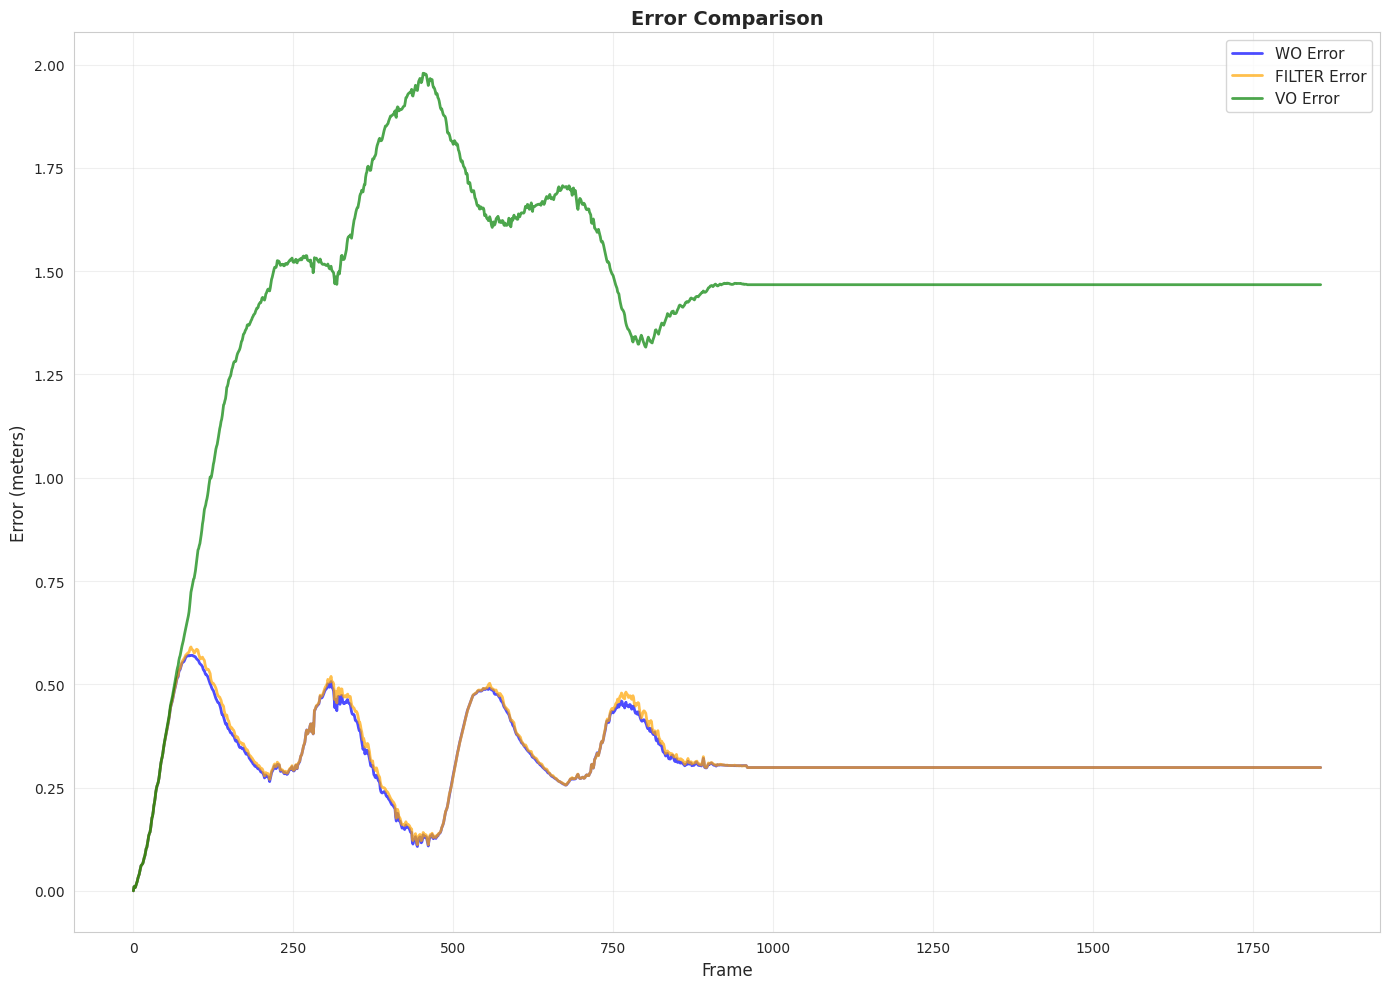

In [19]:
fig, axes = plt.subplots(figsize=(14, 10))


# Dataset 2 - robot_xfeat_bruteforce
# Reload the CSV file with proper handling
df1 = pd.read_csv("/home/aki/Desktop/Python-VO/data/dataset_20260321_115430/XfeatDetector_LighterGlueMatcher_errors.csv", comment='#', on_bad_lines='skip')

# Check the actual columns
print("Columns:", df1.columns.tolist())
print("Shape:", df1.shape)
print(df1.head())
axes.plot(df1['Frame'], df1['WO_Error'], label='WO Error', linewidth=2, color='blue', alpha=0.7)
axes.plot(df1['Frame'], df1['FILTER_Error'], label='FILTER Error', linewidth=2, color='orange', alpha=0.7)
axes.plot(df1['Frame'], df1['VO_Error'], label='VO Error', linewidth=2, color='green', alpha=0.7)
axes.set_xlabel('Frame', fontsize=12)
axes.set_ylabel('Error (meters)', fontsize=12)
axes.set_title('Error Comparison', fontsize=14, fontweight='bold')
axes.legend(fontsize=11)
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Statistical Comparison

In [13]:
# Create summary statistics table
stats_data = {
    'Dataset': ['Robot_Xfeat', 'Robot_Xfeat', 'Robot_Xfeat'],
    'Method': ['VO', 'WO', 'EKF'],
    'Mean Error': [df1['VO_Error'].mean(), df1['WO_Error'].mean(), df1['FILTER_Error'].mean()],
    'Std Dev': [df1['VO_Error'].std(), df1['WO_Error'].std(), df1['FILTER_Error'].std()],
    'Min Error': [df1['VO_Error'].min(), df1['WO_Error'].min(), df1['FILTER_Error'].min()],
    'Max Error': [df1['VO_Error'].max(), df1['WO_Error'].max(), df1['FILTER_Error'].max()]
}

stats_df = pd.DataFrame(stats_data)
print("Error Statistics Comparison:")
print(stats_df.to_string(index=False))

Error Statistics Comparison:
    Dataset Method  Mean Error  Std Dev    Min Error  Max Error
Robot_Xfeat     VO    1.448676 0.305912 1.110223e-16   1.979313
Robot_Xfeat     WO    0.319406 0.084480 1.110223e-16   0.570140
Robot_Xfeat    EKF    0.322932 0.087506 1.110223e-16   0.590398


## Performance Summary

In [18]:
# Performance metrics
print("=" * 70)
print("PERFORMANCE SUMMARY")
print("=" * 70)

print("\n🤖 robot_xfeat_bruteforce Dataset:")
print(f"  Total Frames: {len(df1)}")
print(f"  VO - Mean Error: {df1['VO_Error'].mean():.6f}m (±{df1['VO_Error'].std():.6f}m)")
print(f"  WO - Mean Error: {df1['WO_Error'].mean():.6f}m (±{df1['WO_Error'].std():.6f}m)")
print(f"  EKF - Mean Error: {df1['FILTER_Error'].mean():.6f}m (±{df1['FILTER_Error'].std():.6f}m)")
print(f"  Best Method: {['VO', 'WO', 'EKF'][np.argmin([df1['VO_Error'].mean(), df1['WO_Error'].mean(), df1['FILTER_Error'].mean()])]}")


print("\n✅ Analysis Complete!")
print("=" * 70)

PERFORMANCE SUMMARY

🤖 robot_xfeat_bruteforce Dataset:
  Total Frames: 1857
  VO - Mean Error: 1.448676m (±0.305912m)
  WO - Mean Error: 0.319406m (±0.084480m)
  EKF - Mean Error: 0.322932m (±0.087506m)
  Best Method: WO

✅ Analysis Complete!


In [8]:
from datetime import datetime
import pytz

ts_ns = 1774104871900000000
# Converte para segundos e aplica o fuso de SP/Brasília
dt = datetime.fromtimestamp(ts_ns / 1e9, tz=pytz.timezone('America/Sao_Paulo'))

print(dt.strftime('%d/%m/%Y %H:%M:%S.%f'))

21/03/2026 11:54:31.900000


In [1]:
from datetime import datetime
import pytz

ts_ns = 1774104877249169366
# Converte para segundos e aplica o fuso de SP/Brasília
dt = datetime.fromtimestamp(ts_ns / 1e9, tz=pytz.timezone('America/Sao_Paulo'))

print(dt.strftime('%d/%m/%Y %H:%M:%S.%f'))

21/03/2026 11:54:37.249169


In [6]:
import scipy.io
mat = scipy.io.loadmat('/home/aki/Desktop/old_cuscobot/calibration/calibrationSession.mat')
# 'mat' será um dicionário contendo as variáveis
print(mat.keys())
print(mat['__function_workspace__'])

dict_keys(['__header__', '__version__', '__globals__', 'None', '__function_workspace__'])
[[ 0  1 73 ...  0  0  0]]


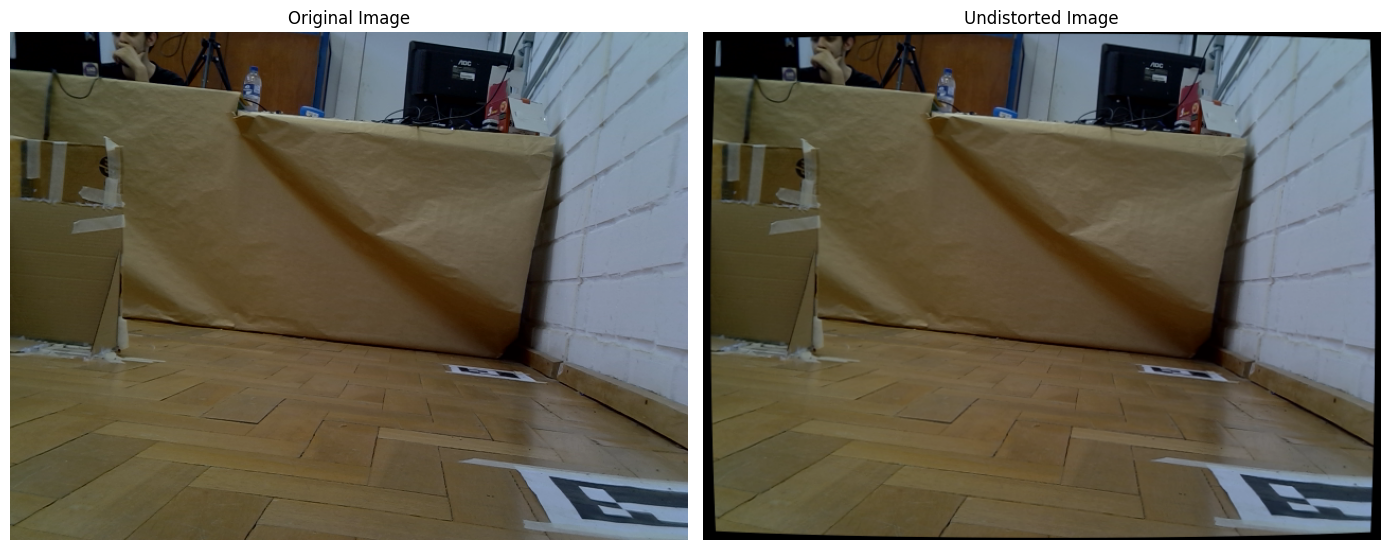

In [19]:

import cv2
import numpy as np
import matplotlib.pyplot as plt


# Exibir a imagem original e a corrigida
img = cv2.imread('/home/aki/Desktop/old_cuscobot/dataset_20260321_115430/stereo_left/1774104875538645258.png')

K = np.array([
    [765.4723,   0.0,     331.6566],
    [0.0,      766.6782,  246.3781],
    [0.0,        0.0,       1.0]
], dtype=np.float64)

dist_coeffs = np.array([0.0844, 0.2218, 0.0, 0.0], dtype=np.float64)
img_undistorted = cv2.undistort(img, K, dist_coeffs)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(img_undistorted, cv2.COLOR_BGR2RGB))
axes[1].set_title('Undistorted Image')
axes[1].axis('off')
plt.tight_layout()
plt.show()


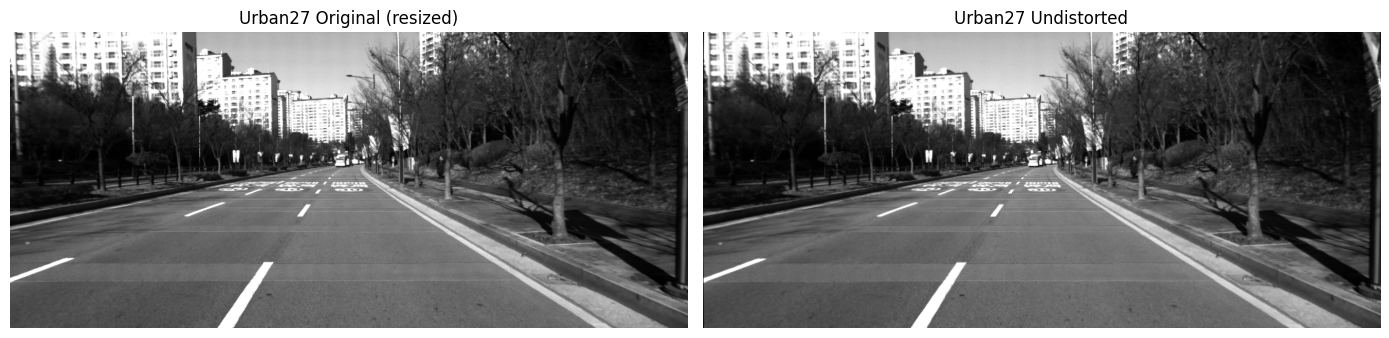

In [17]:
# Exibir a imagem original e a corrigida
img_urban27 = cv2.imread('/home/aki/Desktop/Datasets/urban27-dongtan/urban27/stereo_left/1544582648735466220.png')


camera_matrix_urban27 = np.array([
    [8.1690378992770002e+02, 5.0510166700000003e-01, 6.0850726281690004e+02],
    [0.0, 8.1156803828490001e+02, 2.6347599764440002e+02],
    [0.0, 0.0, 1.0]
], dtype=np.float64)

dist_coeffs_urban27 = np.array([
    -5.6143027800000002e-02,
    1.3952563200000001e-01,
    -1.2155906999999999e-03,
    -9.7281389999999998e-04,
    -8.0878168799999997e-02
], dtype=np.float64)

img_undistorted_urban27 = cv2.undistort(img_urban27, camera_matrix_urban27, dist_coeffs_urban27)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(cv2.cvtColor(img_urban27, cv2.COLOR_BGR2RGB))
axes[0].set_title('Urban27 Original (resized)')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(img_undistorted_urban27, cv2.COLOR_BGR2RGB))
axes[1].set_title('Urban27 Undistorted')
axes[1].axis('off')

plt.tight_layout()
plt.show()

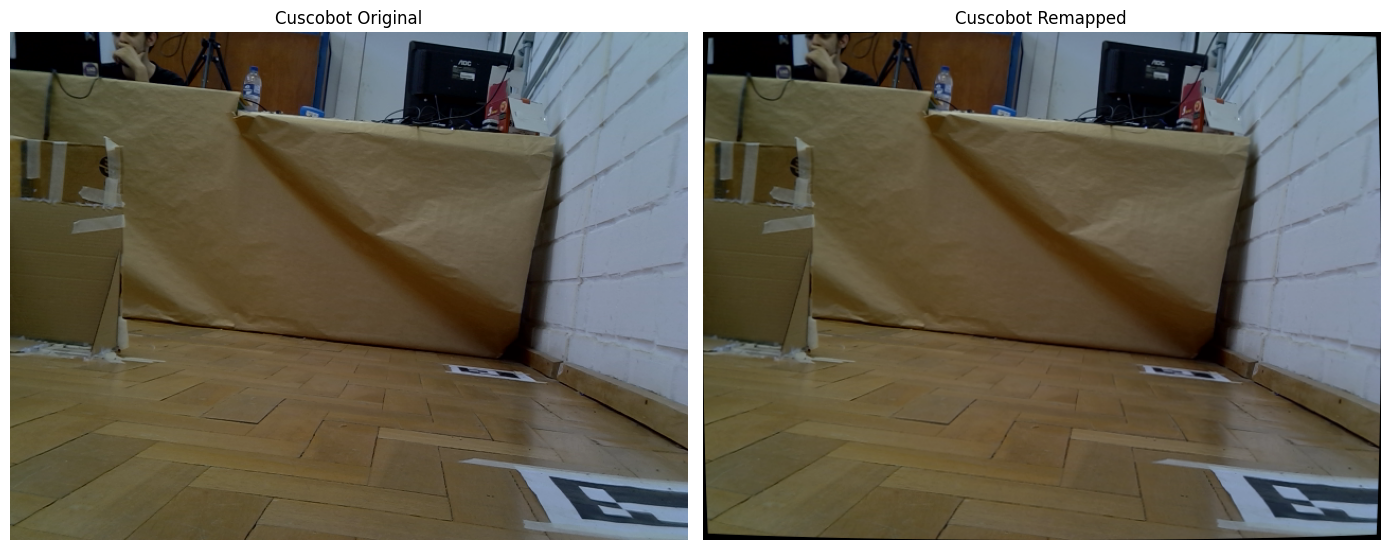

In [21]:
h, w = img.shape[:2]

# Compute the remap for the cuscobot camera
new_K, roi = cv2.getOptimalNewCameraMatrix(K, dist_coeffs, (w, h), alpha=1, newImgSize=(w, h))
map1, map2 = cv2.initUndistortRectifyMap(K, dist_coeffs, None, new_K, (w, h), cv2.CV_16SC2)

img_remapped = cv2.remap(img, map1, map2, interpolation=cv2.INTER_LINEAR)

# Crop to valid ROI if available
x, y, w_roi, h_roi = roi
#if w_roi > 0 and h_roi > 0:
#    img_remapped = img_remapped[y:y+h_roi, x:x+w_roi]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Cuscobot Original')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(img_remapped, cv2.COLOR_BGR2RGB))
axes[1].set_title('Cuscobot Remapped')
axes[1].axis('off')

plt.tight_layout()
plt.show()